X shape: (300, 2)  | convocato shape: (300, 1)
quota convocati: 54.7 %


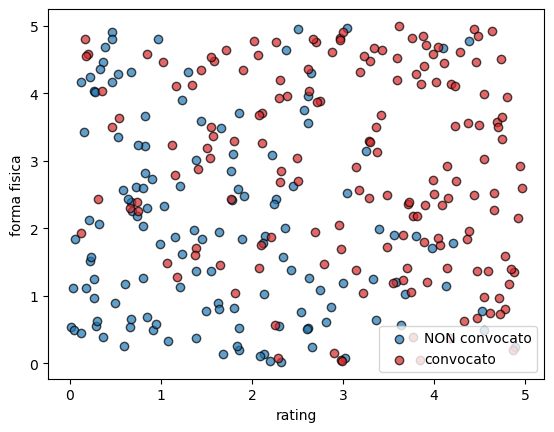

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Scenario: il giocatore viene convocato in nazionale? (sì=1 / no=0)
np.random.seed(7)
rating  = np.random.uniform(0, 5, (300, 1))   # x1
fitness = np.random.uniform(0, 5, (300, 1))   # x2
X = np.hstack([rating, fitness])

# convocato = 0 oppure 1. Non pensare ORA a come lo genero: conta solo che
# rating/forma alti -> più probabile la convocazione, e l'esito è BINARIO.
p = 1/(1+np.exp(-(-4 + 1.0*rating + 0.8*fitness)))
convocato = (np.random.rand(300, 1) < p).astype(float)

print("X shape:", X.shape, " | convocato shape:", convocato.shape)
print("quota convocati:", round(float(convocato.mean()*100), 1), "%")

# guardiamo i dati: convocati (rossi) vs non (blu) sul piano rating-fitness
si = X[convocato[:,0]==1]; no = X[convocato[:,0]==0]
plt.scatter(no[:,0], no[:,1], color='#1f77b4', edgecolors='k', alpha=0.7, label='NON convocato')
plt.scatter(si[:,0], si[:,1], color='#d62728', edgecolors='k', alpha=0.7, label='convocato')
plt.xlabel("rating"); plt.ylabel("forma fisica"); plt.legend(); plt.show()

In [3]:
# Aggiungo la colonna x0 = 1 -> X_b shape (300, 3)
m = X.shape[0]
X_b = np.hstack([np.ones((m, 1)), X])
print("X_b shape:", X_b.shape)

# theta: 3 numeri -> theta0 (base), theta1 (peso rating), theta2 (peso forma)
theta = np.zeros((3, 1))

# Il modello Bernoulli: h(x) = sigmoide(theta^T x) -> una PROBABILITÀ in (0,1)
def sigmoide(z):         return 1/(1+np.exp(-z))
def ipotesi(X_b, theta): return sigmoide(X_b @ theta)

# Con theta = 0: sigmoide(0) = 0.5 -> il modello parte "indeciso", 50% a tutti
print("prime 5 predizioni (theta=0):", ipotesi(X_b, theta)[:5].ravel())

X_b shape: (300, 3)
prime 5 predizioni (theta=0): [0.5 0.5 0.5 0.5 0.5]


In [4]:
alpha = 0.02
theta = np.zeros((3, 1))    # riparto da zero per vedere un update

# giocatore 11: convocato (y=1), rating 4.02, forma 4.17
j = 11
x_i = X_b[j:j+1]
y_i = convocato[j:j+1]
print("giocatore", j, "-> x_i =", x_i.ravel().round(2), "| convocato =", int(y_i.item()))

# 1. predizione attuale (theta = 0)
h_i = ipotesi(x_i, theta)
print("1) predizione attuale:", h_i.ravel().round(3))

# 2. errore (h - y): negativo = ho predetto troppo BASSO (lui era convocato)
print("2) errore (h - y):", (h_i - y_i).ravel().round(3))

# 3. gradiente (h - y) x
gradiente = x_i.T @ (h_i - y_i)
print("3) gradiente (h-y)x:", gradiente.ravel().round(3))
print("3) gradiente (h-y)x:", gradiente.ravel().round(3))

# 4. update
theta = theta - alpha * gradiente
print("4) theta dopo 1 update:", theta.ravel().round(4))
print("   predizione DOPO:", ipotesi(x_i, theta).ravel().round(3))

giocatore 11 -> x_i = [1.   4.02 4.17] | convocato = 1
1) predizione attuale: [0.5]
2) errore (h - y): [-0.5]
3) gradiente (h-y)x: [-0.5   -2.009 -2.086]
3) gradiente (h-y)x: [-0.5   -2.009 -2.086]
4) theta dopo 1 update: [0.01   0.0402 0.0417]
   predizione DOPO: [0.586]


In [9]:
def newton_version():
    theta = np.zeros((3, 1))
    for it in range(8):
      h = ipotesi(X_b, theta)
      S = h * (1 - h)                    # <-- varianza Bernoulli (nella Poisson era h)
      H = X_b.T @ (S * X_b)
      theta = theta - np.linalg.solve(H, X_b.T @ (h - convocato))
      print(f"iter {it} -> theta = {theta.ravel().round(3)}")
    print("theta vero -> [-4, 1, 0.8]")

In [8]:
theta = np.zeros((3, 1))
alpha, epoche = 0.02, 120

for epoca in range(epoche):
  for i in np.random.permutation(m):
      x_i = X_b[i:i+1]; y_i = convocato[i:i+1]
      h_i = ipotesi(x_i, theta)
      gradiente = x_i.T @ (h_i - y_i)        # (h - y) x   <- stesso di sempre
      theta = theta - alpha * gradiente

  if epoca % 20 == 0 or epoca == epoche - 1:
      acc = np.mean((ipotesi(X_b, theta) >= 0.5) == convocato) * 100
      print(f"epoca {epoca:3d} -> theta = {theta.ravel().round(3)}  acc={acc:.0f}%")

print("theta vero          : [-4, 1, 0.8]")

epoca   0 -> theta = [-0.463  0.376 -0.024]  acc=69%
epoca  20 -> theta = [-3.219  0.924  0.465]  acc=78%
epoca  40 -> theta = [-3.56   0.852  0.574]  acc=76%
epoca  60 -> theta = [-3.532  0.901  0.795]  acc=74%
epoca  80 -> theta = [-3.543  1.06   0.589]  acc=76%
epoca 100 -> theta = [-3.52   1.024  0.631]  acc=76%
epoca 119 -> theta = [-3.563  0.918  0.544]  acc=77%
theta vero          : [-4, 1, 0.8]


P(convocato): 0.851
accuracy: 77 %


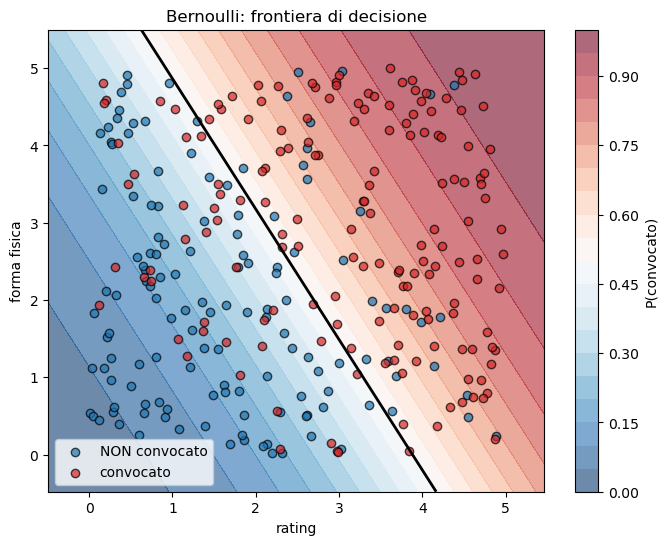

In [13]:
# Predizione per un giocatore nuovo (rating 4, forma 3)
nuovo = np.array([1.0, 4.0, 3.0])         # [x0=1, rating, fitness]
print("P(convocato):", round(float(sigmoide(nuovo @ theta.ravel())), 3))

# Accuracy: classifico "convocato" se P >= 0.5
pred = (ipotesi(X_b, theta) >= 0.5)
print("accuracy:", round(float((pred == convocato).mean()*100)), "%")

# Ora il grafico iconico — la frontiera di decisione (la retta θᵀx = 0, dove P = 0.5):

# Griglia di punti sul piano (rating, forma) per colorare la probabilità predetta
rr, ff = np.meshgrid(np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 200),
                   np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 200))
griglia = np.c_[np.ones(rr.size), rr.ravel(), ff.ravel()]   # aggiungo x0=1
prob = ipotesi(griglia, theta).reshape(rr.shape)

plt.figure(figsize=(8, 6))
sfondo = plt.contourf(rr, ff, prob, levels=20, cmap='RdBu_r', alpha=0.6)
plt.colorbar(sfondo, label='P(convocato)')
plt.contour(rr, ff, prob, levels=[0.5], colors='black', linewidths=2)   # frontiera P=0.5

si = X[convocato[:,0]==1]; no = X[convocato[:,0]==0]
plt.scatter(no[:,0], no[:,1], color='#1f77b4', edgecolors='k', alpha=0.7, label='NON convocato')
plt.scatter(si[:,0], si[:,1], color='#d62728', edgecolors='k', alpha=0.7, label='convocato')
plt.xlabel("rating"); plt.ylabel("forma fisica")
plt.title("Bernoulli: frontiera di decisione"); plt.legend(); plt.show()